In [1]:
# Install and import required packages
!pip install -U scikit-learn imbalanced-learn optuna

# Core imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import optuna

# Data preprocessing
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.utils import resample
from sklearn.model_selection import cross_val_score

# Feature selection
from sklearn.feature_selection import RFECV

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Metrics and evaluation
from sklearn.metrics import (roc_auc_score, classification_report, 
                           confusion_matrix, roc_curve, auc, 
                           precision_recall_curve, f1_score)

# Visualization settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.0 MB 910.3 kB/s eta 0:00:09
   --- ------------------------------------ 0.8/8.0 MB 894.4 kB/s eta 0:00:09
   ----- ---------------------------------- 1.0/8.0 MB 1.0 MB/s eta 0:00:07
   ------ --------------------------------- 1.3/8.0 MB 1.1 MB/s eta 0:00:07
   ------- -------------------------------- 1.6/8.0 MB 1.1 MB/s eta 0:00:06
   ------- -------------------------------- 1.6/8.0 MB 1.1 MB/s eta 0:00:06
   --------- ------------------------------ 1.8/8.0 MB 1.0 MB/s eta 0:00:07
   --------- ------------------------------ 1.8/8.0 MB 1.0 MB/s eta 0:00:07
   ---------- ----------------------------- 2.1/8.0 MB 856.8 kB/s eta 0:00:07
   ---------- --------------------

# 2. Exploratory Data Analysis (EDA): 
**2.1 Initial Data Inspection** :

First we load and inspect the dataset structure and basic statistics

In [2]:
import pandas as pd

df = pd.read_csv("../data/cs-training.csv", sep=";")
df.drop(columns=["Unnamed: 0"], inplace=True)
print(df.shape)
df.head()
display(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nDescriptive stats:")
print(df.describe())
print("\nMissing Values Count:")
print(df.isnull().sum())
print("\nDuplicated Values Count:")
print(df.duplicated().sum())

(150000, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0



Data Types:
SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object

Descriptive stats:
       SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines            age  \
count     150000.000000                         150000.000000  150000.000000   
mean           0.066840                              6.048438      52.295207   
std            0.249746                            249.755371      14.771866   
min            0.000000                              0.000000       0.000000   
25%            0.000000  

# Initial Data Exploration: 
**dataset overview**  : The dataset contains 150,000 entries and 11 columns (after removing the index column Unnamed: 0). It is originally from the Kaggle challenge "Give Me Some Credit" and is used to predict whether a borrower will experience financial distress in the next two years.

**First Look**: Displaying the first 5 rows provides a glimpse into the data structure, showing a mix of behavioral, financial, and personal features for each borrower.

**Data Types**: The dataset includes numerical features only — a mix of integers (age, late payment counts, number of loans) and floats (income, debt ratio, credit utilization). The target variable SeriousDlqin2yrs is binary: 1 means the borrower experienced serious delinquency, 0 means they did not.

**Missing Values**: this dataset does contain missing values in 2 columns — MonthlyIncome has 29,731 missing values (19.8%) and NumberOfDependents has 3,924 missing values (2.6%). 

**2.2 target variable analaysis :**

Examining the distribution of our target variable (Default)




Default Class Distribution:


,Count,Percentage
SeriousDlqin2yrs,,
0,139974,93.316
1,10026,6.684


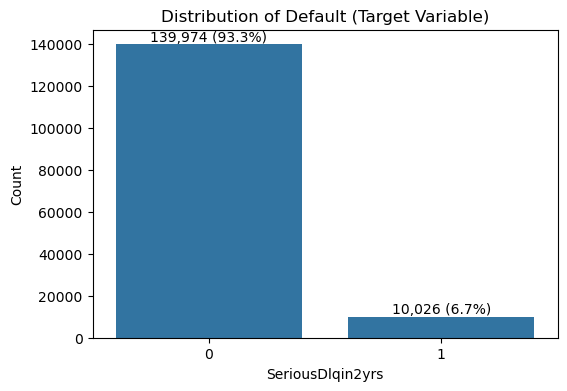

array([1, 0])

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
# Calculate default rate statistics
default_counts = df['SeriousDlqin2yrs'].value_counts()
default_percent = df['SeriousDlqin2yrs'].value_counts(normalize=True) * 100
default_stats = pd.DataFrame({
    'Count': default_counts,
    'Percentage': default_percent
})
print("\nDefault Class Distribution:")
display(default_stats)

# Visualize distribution
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='SeriousDlqin2yrs')
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f} ({p.get_height()/len(df)*100:.1f}%)', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points')
plt.title('Distribution of Default (Target Variable)')
plt.ylabel('Count')
plt.show()

df["SeriousDlqin2yrs"].unique()


# Target Variable Distribution
The target variable SeriousDlqin2yrs shows a clear class imbalance. Approximately 93.32% of borrowers did not experience financial distress (0), while only 6.68% did (1) — representing 10,026 borrowers out of 150,000. 

**3.3 handling missing values** :



                    missing_count  missing_pct
MonthlyIncome               29731        19.82
NumberOfDependents           3924         2.62

Total NaN cells : 33,655
Columns affected: 2


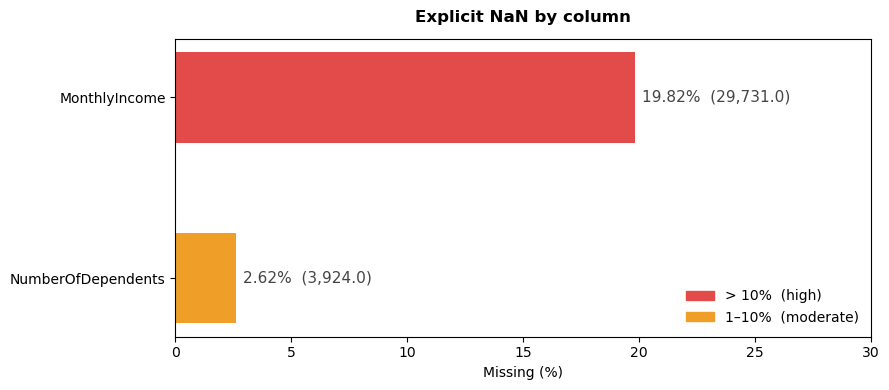

Saved → plot_section2_explicit_nan.png


In [12]:
# Check for missing values (NaN, null, and common placeholders)
from matplotlib import patches


na_count = df.isnull().sum()
na_pct   = (na_count / len(df) * 100).round(2)
na_df    = pd.DataFrame({"missing_count": na_count, "missing_pct": na_pct})
na_df    = na_df[na_df["missing_count"] > 0].sort_values("missing_pct", ascending=False)
 
print(na_df.to_string())
print(f"\nTotal NaN cells : {na_count.sum():,}")
print(f"Columns affected: {(na_count > 0).sum()}")
# ── Plot: Explicit NaN bar chart
fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#E24B4A" if p > 10 else "#EF9F27" for p in na_df["missing_pct"]]
bars = ax.barh(na_df.index, na_df["missing_pct"], color=colors, edgecolor="none", height=0.5)
 
for bar, (col, row) in zip(bars, na_df.iterrows()):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{row["missing_pct"]}%  ({row["missing_count"]:,})',
            va="center", fontsize=11, color="#444")
 
ax.set_xlabel("Missing (%)")
ax.set_title("Explicit NaN by column", fontweight="bold", pad=12)
ax.set_xlim(0, 30)
ax.invert_yaxis()
 
high_patch  = patches.Patch(color="#E24B4A", label="> 10%  (high)")
med_patch   = patches.Patch(color="#EF9F27", label="1–10%  (moderate)")
ax.legend(handles=[high_patch, med_patch], fontsize=10, frameon=False, loc="lower right")
 
plt.tight_layout()
plt.savefig("plot_section2_explicit_nan.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → plot_section2_explicit_nan.png")

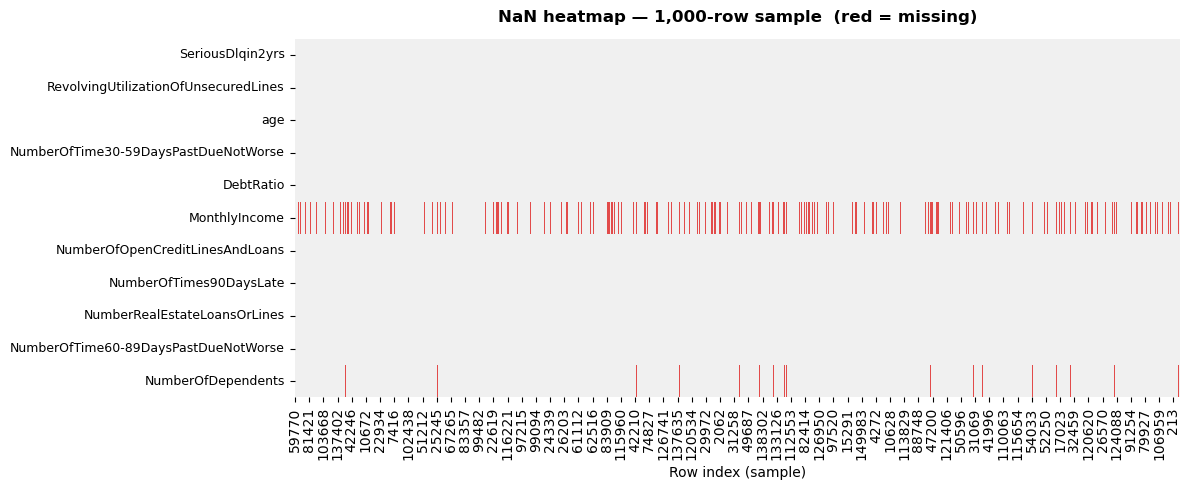

In [13]:
sample = df.sample(1000, random_state=42).isnull()
 
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    sample.T,
    cmap=["#f0f0f0", "#E24B4A"],
    cbar=False,
    ax=ax,
    linewidths=0,
    yticklabels=True,
)
ax.set_title("NaN heatmap — 1,000-row sample  (red = missing)", fontweight="bold", pad=12)
ax.set_xlabel("Row index (sample)")
ax.set_ylabel("")
ax.tick_params(axis="y", labelsize=9)
 
plt.tight_layout()
plt.savefig("plot_section3_nan_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


NumberOfTime30-59DaysPastDueNotWorse
  Value 96 : 5 rows
  Value 98 : 264 rows

NumberOfTimes90DaysLate
  Value 96 : 5 rows
  Value 98 : 264 rows

NumberOfTime60-89DaysPastDueNotWorse
  Value 96 : 5 rows
  Value 98 : 264 rows

Total rows with ANY sentinel: 269


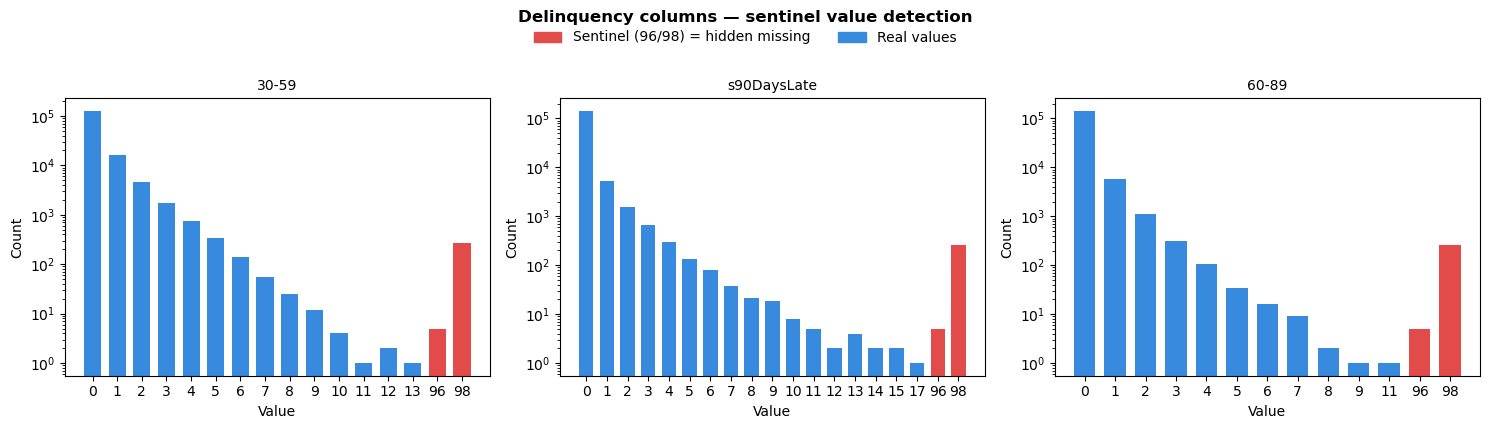

In [15]:
#HIDDEN MISSINGS: SENTINEL VALUES (96 / 98) 
DELINQUENCY_COLS = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
    "NumberOfTime60-89DaysPastDueNotWorse",
]
SENTINELS = [96, 98]
 
for col in DELINQUENCY_COLS:
    vc = df[col].value_counts().sort_index()
    sentinel_counts = {s: int(vc.get(s, 0)) for s in SENTINELS}
    print(f"\n{col}")
    print(f"  Value 96 : {sentinel_counts[96]:,} rows")
    print(f"  Value 98 : {sentinel_counts[98]:,} rows")
 
sentinel_mask = df[DELINQUENCY_COLS].isin(SENTINELS).any(axis=1)
print(f"\nTotal rows with ANY sentinel: {sentinel_mask.sum():,}")
 
# ── Plot: value distributions with sentinels highlighted ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
 
for ax, col in zip(axes, DELINQUENCY_COLS):
    vc = df[col].value_counts().sort_index()
    colors = ["#E24B4A" if v in SENTINELS else "#378ADD" for v in vc.index]
    ax.bar(vc.index.astype(str), vc.values, color=colors, edgecolor="none", width=0.7)
    ax.set_title(col.replace("NumberOfTime", "").replace("DaysPastDueNotWorse", ""), fontsize=10)
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")
    ax.set_yscale("log")
 
sentinel_patch = patches.Patch(color="#E24B4A", label="Sentinel (96/98) = hidden missing")
normal_patch   = patches.Patch(color="#378ADD", label="Real values")
fig.legend(handles=[sentinel_patch, normal_patch], loc="upper center",
           ncol=2, frameon=False, fontsize=10, bbox_to_anchor=(0.5, 1.04))
fig.suptitle("Delinquency columns — sentinel value detection", fontweight="bold", y=1.06)
 
plt.tight_layout()
plt.savefig("plot_section4_sentinels.png", dpi=150, bbox_inches="tight")
plt.show()

  age == 0                            →      1 rows  (0.001%)
  MonthlyIncome == 0                  →  1,634 rows  (1.089%)
  RevolvingUtilization > 1            →  3,321 rows  (2.214%)
  DebtRatio > 1,000                   → 16,892 rows  (11.261%)


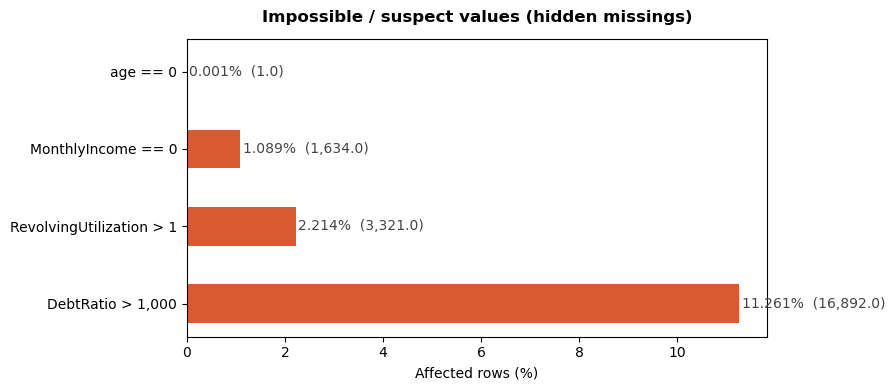

Saved → plot_section5_impossible.png


In [16]:
# HIDDEN MISSINGS: IMPOSSIBLE VALUES
checks = {
    "age == 0":                          df["age"] == 0,
    "MonthlyIncome == 0":               df["MonthlyIncome"] == 0,
    "RevolvingUtilization > 1":         df["RevolvingUtilizationOfUnsecuredLines"] > 1,
    "DebtRatio > 1,000":                df["DebtRatio"] > 1000,
}
 
summary_rows = []
for label, mask in checks.items():
    count = mask.sum()
    pct   = count / len(df) * 100
    summary_rows.append({"issue": label, "count": count, "pct": round(pct, 3)})
    print(f"  {label:<35} → {count:>6,} rows  ({pct:.3f}%)")
 
impossible_df = pd.DataFrame(summary_rows).set_index("issue")
 
# ── Plot: impossible values bar chart ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#D85A30" if p > 1 else "#EF9F27" for p in impossible_df["pct"]]
bars = ax.barh(impossible_df.index, impossible_df["pct"], color=colors, edgecolor="none", height=0.5)
 
for bar, (_, row) in zip(bars, impossible_df.iterrows()):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
            f'{row["pct"]}%  ({row["count"]:,})',
            va="center", fontsize=10, color="#444")
 
ax.set_xlabel("Affected rows (%)")
ax.set_title("Impossible / suspect values (hidden missings)", fontweight="bold", pad=12)
ax.invert_yaxis()
 
plt.tight_layout()
plt.savefig("plot_section5_impossible.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → plot_section5_impossible.png")

Mean DebtRatio (income PRESENT) :       26.6
Mean DebtRatio (income MISSING) :     1673.4
Ratio                           : 63x higher when income is missing


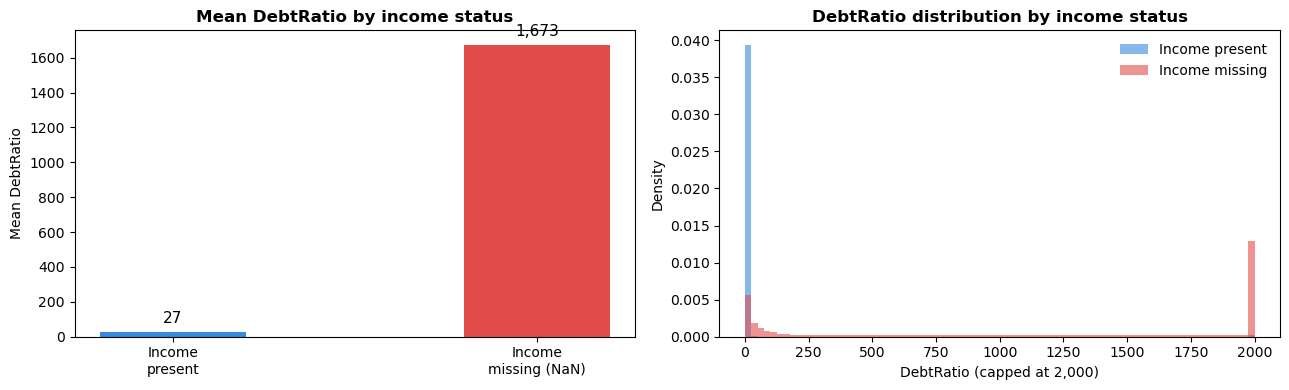

Saved → plot_section6_linked_missingness.png


In [17]:
#LINKED MISSINGNESS: INCOME ↔ DEBTRATIO:
income_missing = df["MonthlyIncome"].isna()
mean_debt_present = df.loc[~income_missing, "DebtRatio"].mean()
mean_debt_missing = df.loc[income_missing,  "DebtRatio"].mean()
 
print(f"Mean DebtRatio (income PRESENT) : {mean_debt_present:>10.1f}")
print(f"Mean DebtRatio (income MISSING) : {mean_debt_missing:>10.1f}")
print(f"Ratio                           : {mean_debt_missing / mean_debt_present:.0f}x higher when income is missing")
 
# ── Plot: side-by-side distributions ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
 
# Bar: mean comparison
ax = axes[0]
groups = ["Income\npresent", "Income\nmissing (NaN)"]
means  = [mean_debt_present, mean_debt_missing]
colors = ["#378ADD", "#E24B4A"]
bars = ax.bar(groups, means, color=colors, edgecolor="none", width=0.4)
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f"{val:,.0f}", ha="center", fontsize=11, fontweight="500")
ax.set_ylabel("Mean DebtRatio")
ax.set_title("Mean DebtRatio by income status", fontweight="bold")
 
# Histogram: DebtRatio distribution (capped at 2000 for readability)
ax = axes[1]
cap = 2000
ax.hist(df.loc[~income_missing, "DebtRatio"].clip(0, cap), bins=80,
        color="#378ADD", alpha=0.6, label="Income present", density=True)
ax.hist(df.loc[income_missing, "DebtRatio"].clip(0, cap), bins=80,
        color="#E24B4A", alpha=0.6, label="Income missing", density=True)
ax.set_xlabel(f"DebtRatio (capped at {cap:,})")
ax.set_ylabel("Density")
ax.set_title("DebtRatio distribution by income status", fontweight="bold")
ax.legend(frameon=False, fontsize=10)
 
plt.tight_layout()
plt.savefig("plot_section6_linked_missingness.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → plot_section6_linked_missingness.png")
 